# Пример использования градиентного спуска для определения минимума функции двух переменных 

$f(x_1, x_2) = (x_1 + 3)^2 + (x_2 - 4)^2 $

Интуитивно понятно, что минимум этой функции достигается
в точке $(x_1 ^* = -3, x_2^* = 4)$

Градиент:

$\frac{\partial f(x_1, x_2)}{\partial x_1} = 2(x_1 + 3)$

$\frac{\partial f(x_1, x_2)}{\partial x_2} = 2(x_2 - 4)$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def obj_function(x1, x2):
  return (x1 + 3)**2 + (x2 - 4)**2

def gradient(x1, x2):
  df_dx1 = 2*(x1 + 3)
  df_dx2 = 2*(x2 - 4)
  return np.array([df_dx1, df_dx2])

In [11]:
max_iters = 1000      # Количество итераций
tolerance = 0.00001   # Точность нахождения минимума
lr = 0.01             # Learning rate
x = np.array([2, -2]) # Инициализация стартовых значений переменных
trajectory = [x.copy()]
losses = [obj_function(x[0], x[1])]
gradients = []

for i in range(max_iters):
    #Считаем градиенты
    grad = gradient(x[0], x[1])
    
    # Проверяем, что значения градиентов не меньше точности
    if np.linalg.norm(grad) < tolerance:
        break
    
    gradients.append(grad)
    x = x - lr*grad  # Обновляем значение переменных X в направлении градиента
    
    trajectory.append(x.copy())
    losses.append(obj_function(x[0], x[1]))

    if i%100 == 0:
        print(f"Итерация {i}/{max_iters}")
    
trajectory = np.array(trajectory)
losses = np.array(losses)

Итерация 0/1000
Итерация 100/1000
Итерация 200/1000
Итерация 300/1000
Итерация 400/1000
Итерация 500/1000
Итерация 600/1000
Итерация 700/1000


In [12]:
print("Найденное значение:", x)

Найденное значение: [-2.9999968   3.99999617]


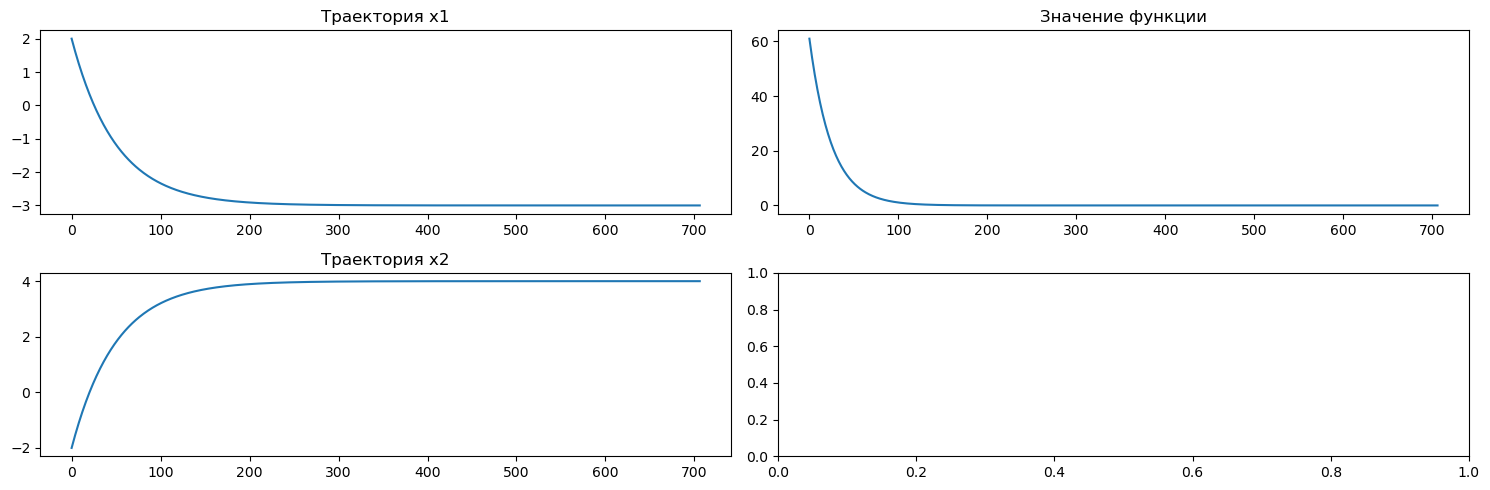

In [13]:
fig, ax = plt.subplots(2, 2, figsize = (15,5))
sns.lineplot(x = range(len(trajectory)), y = trajectory[:, 0], ax = ax[0,0])
ax[0,0].set_title('Траектория х1')
sns.lineplot(x = range(len(trajectory)), y = trajectory[:, 1], ax = ax[1, 0])
ax[1,0].set_title('Траектория х2')
sns.lineplot(x = range(len(losses)), y = losses, ax = ax[0,1])
ax[0,1].set_title('Значение функции')
plt.tight_layout()
plt.show()

# Обучение нейросети с сигмоидой

In [27]:
import numpy as np
import matplotlib.pyplot as plt

Наша задача с помощью нейронной сети аппроксимировать функцию $y = x^2$

Генерируем данные

In [28]:
x = np.linspace(0, 4, 100).reshape(-1,1)
y_true = x**2

Инициализуем веса линейного слоя

In [29]:
np.random.seed(42)
w = np.random.randn()
b = np.random.randn()

In [30]:
print("Стартовое значение w:", w)
print("Стартовое значение b:", b)

Стартовое значение w: 0.4967141530112327
Стартовое значение b: -0.13826430117118466


Задаем константы

In [31]:
learning_rate = 0.01
epochs = 10000
loss_history = []

$ z_i = w \cdot x_i + b$

$\hat{y}_i =  \sigma(z_i)$


Задаем функцию активации и ее производную

In [32]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  s = sigmoid(x)
  return s * (1 - s)

Запускаем обучение

Градиент функции потерь выведен в презентации к лекции

In [33]:
for epoch in range(epochs):
  # Прямой проход
  z = w * x + b
  y_pred = sigmoid(z)

  # Расчет функции потерь
  loss = 0.5*np.mean((y_pred - y_true) ** 2)
  loss_history.append(loss)

  # Обратный проход
  dL_dy_pred = (2/len(x))*(y_pred - y_true)
  dy_pred_dz = sigmoid_derivative(z)
  dz_dw = x
  dz_db = 1

  # Применение цепного правила
  dL_dw = np.sum(dL_dy_pred * dy_pred_dz * dz_dw)
  dL_db = np.sum(dL_dy_pred * dy_pred_dz * dz_db)

  # Обновление параметров
  w = w - learning_rate * dL_dw
  b = b - learning_rate * dL_db

  if epoch % 500 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f}")

Epoch    0 | Loss: 22.004514 | w: 0.5410 | b: -0.1236
Epoch  500 | Loss: 21.108531 | w: 1.9654 | b: 0.2708
Epoch 1000 | Loss: 21.101806 | w: 2.2132 | b: 0.2132
Epoch 1500 | Loss: 21.098428 | w: 2.3684 | b: 0.1162
Epoch 2000 | Loss: 21.095771 | w: 2.4867 | b: 0.0044
Epoch 2500 | Loss: 21.093392 | w: 2.5858 | b: -0.1137
Epoch 3000 | Loss: 21.091185 | w: 2.6735 | b: -0.2336
Epoch 3500 | Loss: 21.089125 | w: 2.7541 | b: -0.3523
Epoch 4000 | Loss: 21.087211 | w: 2.8298 | b: -0.4681
Epoch 4500 | Loss: 21.085443 | w: 2.9021 | b: -0.5797
Epoch 5000 | Loss: 21.083821 | w: 2.9717 | b: -0.6863
Epoch 5500 | Loss: 21.082340 | w: 3.0391 | b: -0.7876
Epoch 6000 | Loss: 21.080991 | w: 3.1045 | b: -0.8836
Epoch 6500 | Loss: 21.079765 | w: 3.1681 | b: -0.9742
Epoch 7000 | Loss: 21.078650 | w: 3.2298 | b: -1.0598
Epoch 7500 | Loss: 21.077636 | w: 3.2899 | b: -1.1406
Epoch 8000 | Loss: 21.076713 | w: 3.3482 | b: -1.2170
Epoch 8500 | Loss: 21.075871 | w: 3.4048 | b: -1.2892
Epoch 9000 | Loss: 21.075101 | w

In [35]:
print("Финальное значение w:", w)
print("Финальное значение b:", b)

Финальное значение w: 3.5646416561318883
Финальное значение b: -1.4839318841972857


Посмотрим на качество аппроксимации

In [36]:
z = w * x + b
y_pred = sigmoid(z)

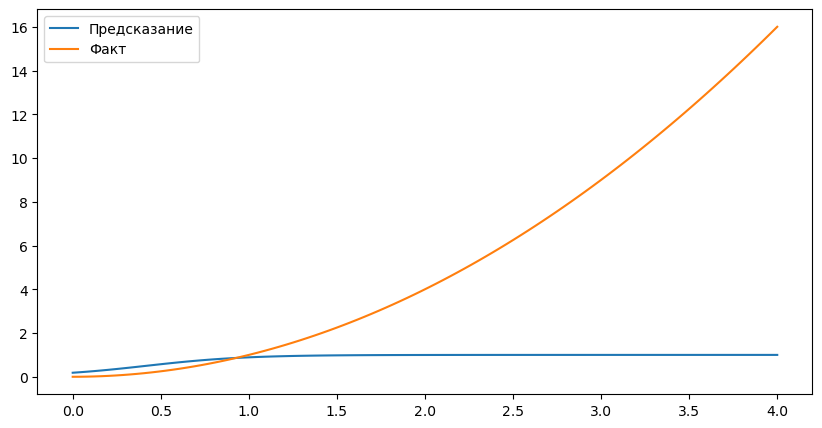

In [39]:
fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# Обучение нейросети с ReLU и одним скрытым слоем из одного нейрона

In [40]:
import pandas as pd

Соберем нейронную сеть из двух линейных слоев и одной функции активации ReLU между ними:

$\hat{y}_i = a \cdot h_i + c$

$ h_i = max(0, z_i) $

$ z_i = w \cdot x_i + b$

Для работы нейронной сети нам нужно знать 4 параметра: $w, b, a, c$

Целиком функция выглядит как: $\hat{y}_i = a \cdot max(0, w \cdot x_i + b) + c$

Незвестные параметры будем подбирать с помощью градиентного спуска, находя минимум функции потерь: $L(w, b, a, c) = \frac{1}{n} \sum_{i=1}^{n}{(\hat{y}_i - y_i)^2}$

Инициализация весов

In [42]:
np.random.seed(42)

w = np.random.randn()
b = np.random.randn()
a = np.random.randn()
c = np.random.randn()

print("Веса до обучения")
print("w:", w, "b:", b, "a:", a, "c:", c)

Веса до обучения
w: 0.4967141530112327 b: -0.13826430117118466 a: 0.6476885381006925 c: 1.5230298564080254


Найдем градиент функции потерь по неизвестным параметрам:

$\frac{\partial L}{\partial w}= \sum_{i=1}^{n}{\left( \frac{2}{n}(\hat{y}_i - y_i) \cdot a \cdot \frac{\partial h_i}{\partial z_i} \cdot x_i \right)}$

$\frac{\partial L}{\partial b}= \sum_{i=1}^{n}{\left( \frac{2}{n}(\hat{y}_i - y_i) \cdot a \cdot \frac{\partial h_i}{\partial z_i} \cdot 1 \right)}$

$\frac{\partial L}{\partial a}= \sum_{i=1}^{n}{\left(\frac{2}{n}(\hat{y}_i - y_i) \cdot h_i\right)}$

$\frac{\partial L}{\partial c}=\sum_{i=1}^{n}{\left(\frac{2}{n}(\hat{y}_i - y_i) \cdot 1\right)}$


Для этого будем последовательно двигаться по нейронной сети задом наперед:

$\frac{\partial L}{\partial \hat{y}_i}= \frac{2}{n}(\hat{y}_i - y_i)$

$\frac{\partial \hat{y}_i}{\partial a} = h_i$

$\frac{\partial \hat{y}_i}{\partial h_i} = a$

$\frac{\partial \hat{y}_i}{\partial c} = 1$

$\frac{\partial h_i}{\partial z_i} = 1 \text{ для } z_i > 0 \text{ и } 0 \text{ для } z_i \leq 0$

$\frac{\partial z_i}{\partial w} = x_i$

$\frac{\partial z_i}{\partial b} = 1$

Создаем функции ReLU и ее производной

In [43]:
def relu(x):
  return np.maximum(0, x)

def drelu(x):
  return (x > 0).astype(float)

Задаем константы

In [44]:
lr = 0.001
epochs = 10000
loss_history = []

Запускаем обучение нейросети

In [45]:
for epoch in range(epochs):
  # Прямой проход (forward pass)
  z = w * x + b
  h = relu(z)
  y_pred = a * h + c

  # Считаем функцию потерь
  loss = np.mean((y_true - y_pred)**2)
  loss_history.append(loss)

  # Обратный проход (backward pass)
  dL_dy_pred = (2/len(x))*(y_pred - y_true)
  dL_da = np.sum(dL_dy_pred*h)
  dL_dc = np.sum(dL_dy_pred)
  dL_dh = dL_dy_pred * a
  dL_dz = dL_dh * drelu(z)
  dL_dw = np.sum(dL_dz * x)
  dL_db = np.sum(dL_dz)

  # Обновляем веса
  w = w - lr * dL_dw
  b = b - lr * dL_db
  a = a - lr * dL_da
  c = c - lr * dL_dc

  # Выводим информацию о процессе обучения для каждой 200й эпохи
  if epoch % 200 == 0:
    print(f"Epoch {epoch:4d} | Loss: {loss:.6f} | w: {w:.4f} | b: {b:.4f} | a: {a:.4f} | c: {c:.4f}")

Epoch    0 | Loss: 30.674882 | w: 0.5117 | b: -0.1339 | a: 0.6583 | c: 1.5296
Epoch  200 | Loss: 4.863671 | w: 1.5807 | b: -0.3072 | a: 1.6560 | c: 1.4907
Epoch  400 | Loss: 3.044790 | w: 1.6590 | b: -0.7701 | a: 1.8692 | c: 1.1821
Epoch  600 | Loss: 1.916360 | w: 1.6995 | b: -1.1241 | a: 2.0736 | c: 0.9470
Epoch  800 | Loss: 1.239543 | w: 1.7254 | b: -1.3923 | a: 2.2501 | c: 0.7722
Epoch 1000 | Loss: 0.844214 | w: 1.7441 | b: -1.5947 | a: 2.3943 | c: 0.6447
Epoch 1200 | Loss: 0.616320 | w: 1.7581 | b: -1.7482 | a: 2.5089 | c: 0.5534
Epoch 1400 | Loss: 0.485832 | w: 1.7685 | b: -1.8649 | a: 2.5986 | c: 0.4894
Epoch 1600 | Loss: 0.410272 | w: 1.7762 | b: -1.9548 | a: 2.6690 | c: 0.4461
Epoch 1800 | Loss: 0.366742 | w: 1.7818 | b: -2.0240 | a: 2.7238 | c: 0.4178
Epoch 2000 | Loss: 0.340630 | w: 1.7862 | b: -2.0784 | a: 2.7673 | c: 0.4009
Epoch 2200 | Loss: 0.324667 | w: 1.7888 | b: -2.1220 | a: 2.8018 | c: 0.3922
Epoch 2400 | Loss: 0.315139 | w: 1.7910 | b: -2.1558 | a: 2.8289 | c: 0.389

In [46]:
print("Веса после обучения")
print("w:", w, "b:", b, "a:", a, "c:", c)

Веса после обучения
w: 1.7853874480886367 b: -2.3630957225927416 a: 2.9865528285758476 c: 0.5603857991985127


Обученная нейросеть для аппроксимации параболы выглядит так:

$\hat{y}_i = 2.99 \cdot h_i + 0.56$

$ h_i = max(0, z_i) $

$ z_i = 1.785 \cdot x_i -2.36$

Применяем обученную нейронную сеть к данным

In [47]:
z = w * x + b
h = relu(z)
y_pred = a * h + c

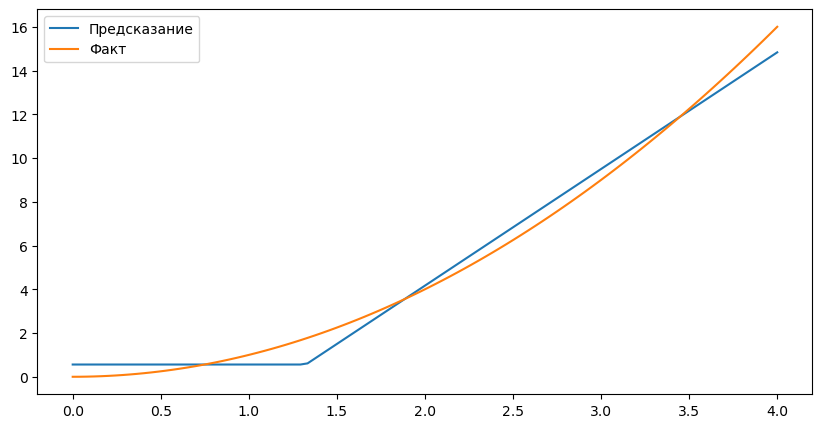

In [48]:
fig, ax = plt.subplots(1,1,figsize = (10, 5))
ax.plot(x, y_pred, label = "Предсказание")
ax.plot(x, y_true, label = "Факт")
ax.legend()
plt.show()

# Обучение нейросети с ReLU и одним скрытым слоем из двух нейронов

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x = np.linspace(0, 4, 100).reshape(-1,1)
y_true = x**2

Соберем нейронную сеть из двух линейных слоев и одной функции активации ReLU между ними:

$\hat{y}_i = a_1 \cdot h_{1i} + a_2 \cdot h_{2i} + c$

$ h_{1i} = max(0, z_{1i}) $

$ h_{2i} = max(0, z_{2i}) $

$ z_{1i} = w_1 \cdot x_i + b_1$

$ z_{2i} = w_2 \cdot x_i + b_2$

Для работы нейронной сети нам нужно знать 7 параметров: $w_1, w_2, b_1, b_2, a_1, a_2, c$

Целиком функция выглядит как: $\hat{y}_i = a_1 \cdot max(0, w_1 \cdot x_i + b_1) + a_2 \cdot max(0, w_2 \cdot x_i + b_2) + c$

Инициализация весов

In [ ]:
n_neurons = 2

In [ ]:
np.random.seed(42)
# Скрытый слой (2 нейрона)
w = np.random.randn(n_neurons)
b = np.random.randn(n_neurons)

# Выходящий слой
a = np.random.randn(n_neurons)
c = np.random.randn()

Задаем константы

In [ ]:
# Гиперпараметры
lr = 0.01
epochs = 4000
loss_history = []

In [ ]:
# ReLU и ее производная
def relu(x):
    return np.maximum(0, x)

def drelu(x):
    return (x > 0).astype(float)

Запускаем обучение нейросети

In [ ]:
for epoch in range(epochs):
    # Прямой проход
    z = x @ w.reshape(1, -1) + b  # размер (n, 2)
    h = relu(z)                   # активация скрытого слоя
    y_pred = h @ a.reshape(-1, 1) + c  # выходной слой, размер (n, 1)

    # Считаем функцию потерь
    loss = np.mean((y_true - y_pred)**2)
    loss_history.append(loss)

    # Обратный проход
    dL_dy = 2 * (y_pred - y_true) / len(x)  # shape (N, 1)

    # Градиеты для выходного слоя
    dL_da = np.sum(dL_dy * h, axis=0)       # (2,)
    dL_dc = np.sum(dL_dy)                   # scalar

    # Градиенты для скрытого слоя
    dL_dh = dL_dy @ a.reshape(1, -1)        # (N, 2)
    dL_dz = dL_dh * drelu(z)                # (N, 2)
    dL_dw = np.sum(dL_dz * x, axis=0)       # (2,)
    dL_db = np.sum(dL_dz, axis=0)           # (2,)

    # Обновление весов градиентным спуском
    w -= lr * dL_dw
    b -= lr * dL_db
    a -= lr * dL_da
    c -= lr * dL_dc

    # Выводим информацию о процессе обучения для каждой 200й эпохи
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

Epoch    0 | Loss: 44.033571
Epoch  200 | Loss: 0.993374
Epoch  400 | Loss: 0.402755
Epoch  600 | Loss: 0.259600
Epoch  800 | Loss: 0.241317
Epoch 1000 | Loss: 0.237748
Epoch 1200 | Loss: 0.236000
Epoch 1400 | Loss: 0.233891
Epoch 1600 | Loss: 0.231098
Epoch 1800 | Loss: 0.228997
Epoch 2000 | Loss: 0.226964
Epoch 2200 | Loss: 0.224973
Epoch 2400 | Loss: 0.223062
Epoch 2600 | Loss: 0.221184
Epoch 2800 | Loss: 0.219364
Epoch 3000 | Loss: 0.217607
Epoch 3200 | Loss: 0.215040
Epoch 3400 | Loss: 0.212602
Epoch 3600 | Loss: 0.210495
Epoch 3800 | Loss: 0.208441


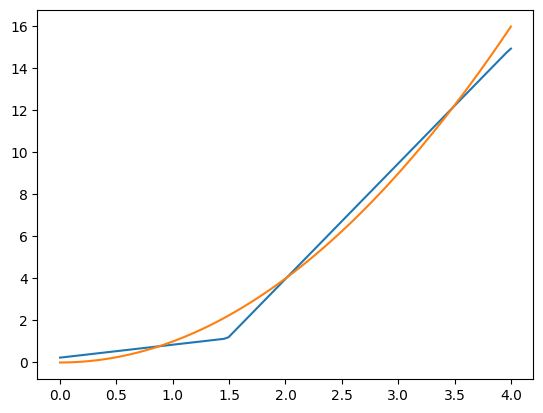

In [ ]:
plt.plot(x, y_pred)
plt.plot(x, y_true)

In [ ]:
print("Веса после обучения")
print("w1:", w[0], "w2:", w[1],"b1:", b[0], "b2:", b[1], "a1:", a[0], "a2:", a[1], "c:", c)

Веса после обучения
w1: 1.6761828908598986 w2: -0.48191106921074733 b1: -2.488074768687457 b2: 1.9086627540567203 a1: 2.9125534017944443 a2: -1.2772159259891644 c: 2.6681116354273042


$\hat{y}_i = 2.91 \cdot max(0, 1.68 \cdot x_i - 2.49) -1.28 \cdot max(0, -0.48 \cdot x_i + 1.91) + 2.67$

# Обучение нейросети с сигмоидой и двумя нейронами

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
N = 300  # samples per class
D = 2    # input dimension
K = 3    # number of classes

X = np.zeros((N*K, D))
y = np.zeros((N*K, K))  # one-hot labels

for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix, j] = 1

In [ ]:
H = 5  # hidden neurons

w = 0.01 * np.random.randn(D, H)
b = np.zeros((1, H))
a = 0.01 * np.random.randn(H, K)
c = np.zeros((1, K))

Определяем функции сигмоиды, поизводной и софтмакс

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Задаем константы

In [ ]:
lr = 1.0
epochs = 10000
loss_history = []

Запускаем обучение

In [ ]:
for epoch in range(epochs):
    # ---- Forward pass ----
    z = X @ w + b
    h = sigmoid(z)
    logits = h @ a + c
    y_pred = softmax(logits)

    # ---- Compute loss (cross-entropy) ----
    loss = -np.mean(np.sum(y * np.log(y_pred + 1e-8), axis=1))
    loss_history.append(loss)

    # ---- Backpropagation ----
    dL_dlogits = (y_pred - y) / (N*K)
    dL_da= h.T @ dL_dlogits
    dL_dc = np.sum(dL_dlogits, axis=0, keepdims=True)

    dL_dh = dL_dlogits @ a.T
    dL_dz = dL_dh * dsigmoid(z)
    dL_dw = X.T @ dL_dz
    dL_db = np.sum(dL_dz, axis=0, keepdims=True)

    # ---- Gradient descent update ----
    w -= lr * dL_dw
    b -= lr * dL_db
    a -= lr * dL_da
    c -= lr * dL_dc

    # Print progress occasionally
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.4f}")

Epoch     0 | Loss: 1.0986
Epoch   500 | Loss: 0.7281
Epoch  1000 | Loss: 0.4792
Epoch  1500 | Loss: 0.2519
Epoch  2000 | Loss: 0.1772
Epoch  2500 | Loss: 0.1454
Epoch  3000 | Loss: 0.1271
Epoch  3500 | Loss: 0.1147
Epoch  4000 | Loss: 0.1054
Epoch  4500 | Loss: 0.0982
Epoch  5000 | Loss: 0.0924
Epoch  5500 | Loss: 0.0875
Epoch  6000 | Loss: 0.0834
Epoch  6500 | Loss: 0.0798
Epoch  7000 | Loss: 0.0767
Epoch  7500 | Loss: 0.0739
Epoch  8000 | Loss: 0.0714
Epoch  8500 | Loss: 0.0692
Epoch  9000 | Loss: 0.0672
Epoch  9500 | Loss: 0.0653


Оценваем качество классификации

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y, axis=1)
print(classification_report(y_true_class, y_pred_class))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       300
           1       0.99      0.99      0.99       300
           2       0.98      1.00      0.99       300

    accuracy                           0.99       900
   macro avg       0.99      0.99      0.99       900
weighted avg       0.99      0.99      0.99       900



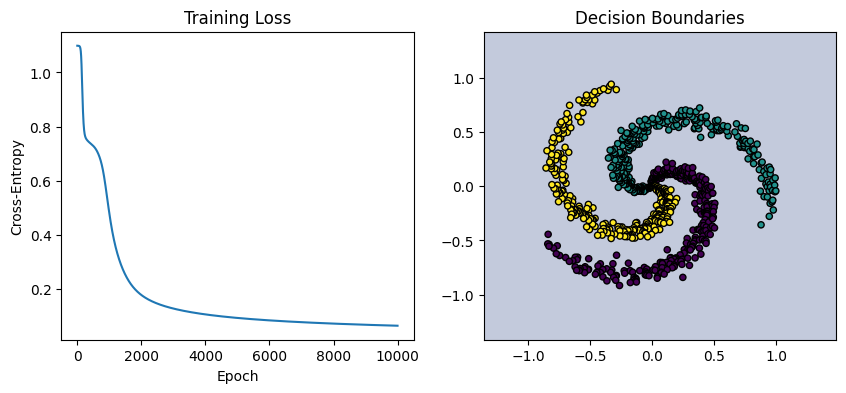

In [ ]:
# === 7. Plot loss and decision boundaries ===
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy")

# Decision boundary
plt.subplot(1,2,2)
h_step = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h_step),
                     np.arange(y_min, y_max, h_step))
grid = np.c_[xx.ravel(), yy.ravel()]
h_grid = sigmoid(grid @ W1 + b1)
scores = h_grid @ W2 + b2
Z = np.argmax(softmax(scores), axis=1).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), s=20, edgecolor='k')
plt.title("Decision Boundaries")
plt.show()

Финальный вид обученной нейронки

In [ ]:
w

array([[-5.91274723, 11.60803291,  5.58897343, 24.89502848,  0.52035838],
       [-5.91858783,  7.85768221, -9.67696555, -1.94846235, 13.12287333]])

In [ ]:
b

array([[-0.84703852, -5.41384146,  6.61525459, -0.14542019,  6.06210846]])

In [ ]:
a

array([[-11.82831188,  -5.47964512,  17.2998077 ],
       [ -4.63910492,  14.01836448,  -9.39526538],
       [  9.93398827,   6.24162591, -16.16137935],
       [  3.34850122, -13.7357455 ,  10.37975456],
       [-16.56510468,   6.61923435,   9.94092878]])

In [ ]:
c

array([[ 8.85833264, -5.36868451, -3.48964813]])

Первый нейрон:

$z_{1i} = -5.913 \cdot x_{1i} - 5.919 \cdot x_{2i} - 0.847$

$...$

$z_{5i} = 0.52 \cdot x_{1i} +13.123 \cdot x_{2i} + 6.062$

$class\_1\_logit_i = -11.828 \cdot \sigma(z_{1i}) ... -16.565 \cdot \sigma(z_{5i}) + 8.858$

$class\_2\_logit_i = -5.480 \cdot \sigma(z_{1i}) ... + 6.619 \cdot \sigma(z_{5i}) - 5.369$

$class\_3\_logit_i = 17.300 \cdot \sigma( z_{1i}) ... + 9.941 \cdot \sigma(z_{5i}) - 3.490$

$prob(y_i = class\_1) = \frac{e^{class\_1\_logit_i}}{e^{class\_1\_logit_i} + e^{class\_2\_logit_i} + e^{class\_3\_logit_i}}$

$prob(y_i = class\_2) = \frac{e^{class\_2\_logit_i}}{e^{class\_1\_logit_i} + e^{class\_2\_logit_i} + e^{class\_3\_logit_i}}$

$prob(y_i = class\_3) = \frac{e^{class\_3\_logit_i}}{e^{class\_1\_logit_i} + e^{class\_2\_logit_i} + e^{class\_3\_logit_i}}$